*  DSC640-T301 Data Presentation & Visualizat (2263-1)
*  Weeks 1 & 2 Assignment - Netflix Viewership
*  Charles Sarratt

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Netflix-inspired color palette
colors = {
    "TV (English)": "#E50914",        # Netflix red
    "TV (Non-English)": "#A1A1A1",    # medium gray
    "Films (English)": "#3C3C3C",     # dark gray
    "Films (Non-English)": "#757575"  # softer gray
}

accent_red = "#E50914"
accent_gray = "#A1A1A1"

# Show more rows while exploring
pd.set_option("display.max_rows", 20)

countries = pd.read_excel("most-popular_global_weekly.xlsx")
global_df = pd.read_excel("most-popular_global_alltime.xlsx")
popular = pd.read_excel("most-popular_country_weekly.xlsx")

countries.head(), global_df.head(), popular.head()

(  country_name country_iso2        week category  weekly_rank  \
 0    Argentina           AR  2025-11-30    Films            1   
 1    Argentina           AR  2025-11-30    Films            2   
 2    Argentina           AR  2025-11-30    Films            3   
 3    Argentina           AR  2025-11-30    Films            4   
 4    Argentina           AR  2025-11-30    Films            5   
 
            show_title season_title  cumulative_weeks_in_top_10  
 0   A Man Called Otto          NaN                           2  
 1   Jingle Bell Heist          NaN                           1  
 2  Champagne Problems          NaN                           2  
 3        Train Dreams          NaN                           1  
 4  KPop Demon Hunters          NaN                          24  ,
          week         category  weekly_rank          show_title season_title  \
 0  2025-11-30  Films (English)            1   Jingle Bell Heist          NaN   
 1  2025-11-30  Films (English)            

In [2]:
# Global totals by category
global_totals = (
    global_df
    .groupby("category", as_index=False)["weekly_hours_viewed"]
    .sum()
    .sort_values("weekly_hours_viewed", ascending=False)
)

# TV only, for the time series
tv_global = global_df[global_df["category"].isin(["TV (English)", "TV (Non-English)"])]

tv_trend = (
    tv_global
    .groupby(["week", "category"], as_index=False)["weekly_hours_viewed"]
    .sum()
    .sort_values(["week", "category"])
)

# Country-level summary: max number of countries in a single week for each title
weekly_country_counts = (
    countries
    .groupby(["show_title", "week"], as_index=False)["country_iso2"]
    .nunique()
    .rename(columns={"country_iso2": "num_countries_this_week"})
)

title_country_reach = (
    weekly_country_counts
    .groupby("show_title", as_index=False)["num_countries_this_week"]
    .max()
    .rename(columns={"num_countries_this_week": "max_countries"})
    .sort_values("max_countries", ascending=False)
)

title_country_reach.head()

,show_title,max_countries
2525,Emily in Paris,94
10260,You,94
9188,The Tinder Swindler,94
9239,The Unforgivable,94
7427,Squid Game,94


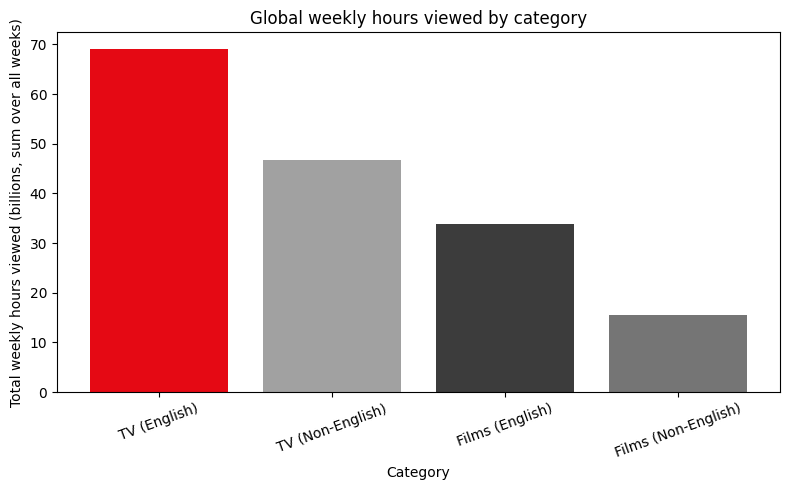

In [3]:
# Global weekly hours viewed by category - Netflix colors

plt.figure(figsize=(8, 5))

values_billion = global_totals["weekly_hours_viewed"] / 1e9
bar_colors = [colors[c] for c in global_totals["category"]]

plt.bar(global_totals["category"], values_billion, color=bar_colors)

plt.title("Global weekly hours viewed by category")
plt.xlabel("Category")
plt.ylabel("Total weekly hours viewed (billions, sum over all weeks)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

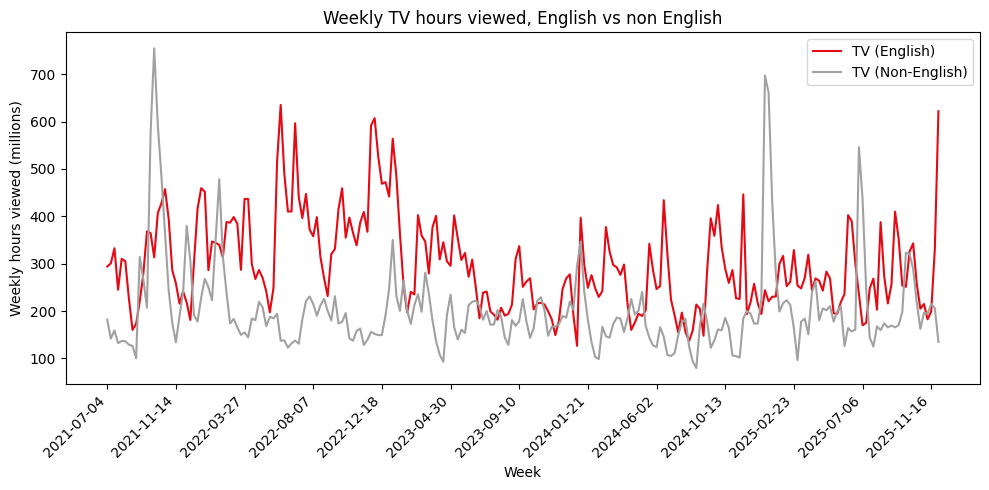

In [4]:
# Weekly TV hours viewed, English vs non English - in millions

plt.figure(figsize=(10, 5))

for cat, grp in tv_trend.groupby("category"):
    plt.plot(
        grp["week"],
        grp["weekly_hours_viewed"] / 1e6,   # Convert to millions
        label=cat,
        color=colors.get(cat, accent_gray)
    )

plt.title("Weekly TV hours viewed, English vs non English")
plt.xlabel("Week")
plt.ylabel("Weekly hours viewed (millions)")

# Reduce x-axis clutter
weeks = tv_trend["week"].sort_values().unique()
step = max(1, len(weeks) // 12)
plt.xticks(weeks[::step], rotation=45, ha="right")

plt.legend()
plt.tight_layout()
plt.show()

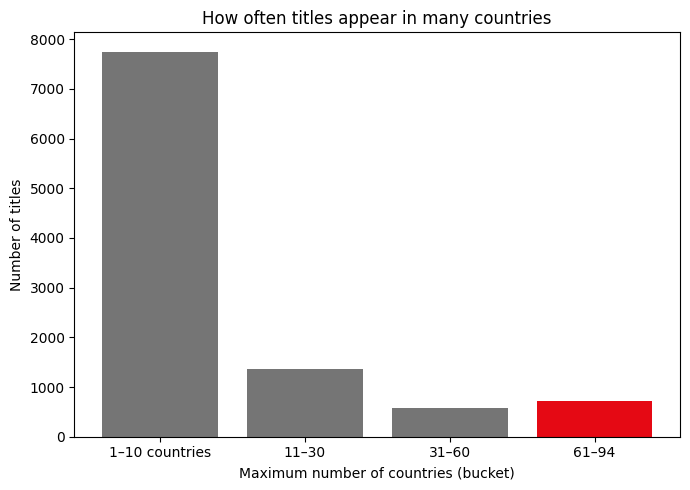

,reach_bucket,num_titles
0,1–10 countries,7752
1,11–30,1366
2,31–60,570
3,61–94,714


In [5]:
# Bucket distribution of max country reach + Netflix colors

bins = [0, 10, 30, 60, 94]
labels = ["1–10 countries", "11–30", "31–60", "61–94"]

title_country_reach["reach_bucket"] = pd.cut(
    title_country_reach["max_countries"],
    bins=bins,
    labels=labels
)

bucket_counts = (
    title_country_reach
    .groupby("reach_bucket", as_index=False, observed=False)["show_title"]
    .count()
    .rename(columns={"show_title": "num_titles"})
)

# Use red for the rare global bucket, gray for others
bucket_color_map = {
    "1–10 countries": "#757575",
    "11–30": "#757575",
    "31–60": "#757575",
    "61–94": "#E50914"
}

bar_colors = [
    bucket_color_map.get(str(label), accent_gray)
    for label in bucket_counts["reach_bucket"]
]

plt.figure(figsize=(7, 5))
plt.bar(
    bucket_counts["reach_bucket"].astype(str),
    bucket_counts["num_titles"],
    color=bar_colors
)

plt.title("How often titles appear in many countries")
plt.xlabel("Maximum number of countries (bucket)")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.show()

bucket_counts

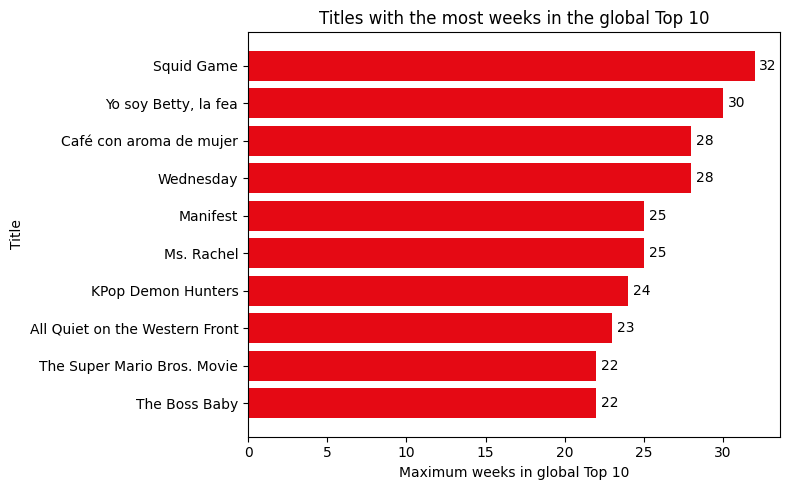

,show_title,cumulative_weeks_in_top_10
2076,Squid Game,32
2921,"Yo soy Betty, la fea",30
422,Café con aroma de mujer,28
2852,Wednesday,28
1465,Manifest,25
1589,Ms. Rachel,25
1226,KPop Demon Hunters,24
148,All Quiet on the Western Front,23
2541,The Super Mario Bros. Movie,22
2213,The Boss Baby,22


In [6]:
# Titles with the most weeks in the global Top 10 - Netflix colors

top_weeks = (
    global_df
    .groupby("show_title", as_index=False)["cumulative_weeks_in_top_10"]
    .max()
    .sort_values("cumulative_weeks_in_top_10", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_weeks["show_title"],
    top_weeks["cumulative_weeks_in_top_10"],
    color=accent_red
)
plt.gca().invert_yaxis()

plt.title("Titles with the most weeks in the global Top 10")
plt.xlabel("Maximum weeks in global Top 10")
plt.ylabel("Title")
for i, v in enumerate(top_weeks["cumulative_weeks_in_top_10"]):
    plt.text(v + 0.3, i, str(v), va='center')
plt.tight_layout()
plt.show()

top_weeks

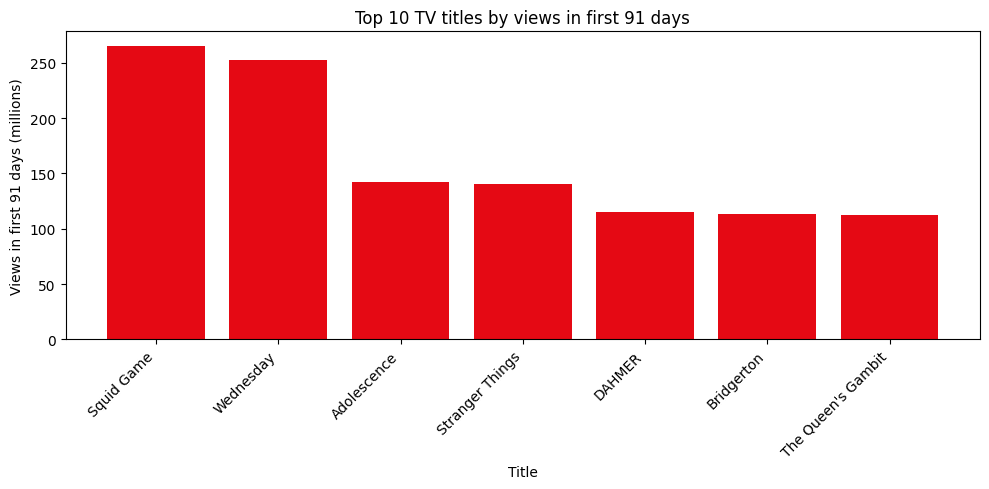

,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
30,TV (Non-English),1,Squid Game,Squid Game: Season 1,2205200000,8.3167,265200000
20,TV (English),1,Wednesday,Wednesday: Season 1,1718800000,6.8167,252100000
31,TV (Non-English),2,Squid Game,Squid Game: Season 2,1380100000,7.1667,192600000
32,TV (Non-English),3,Squid Game,Squid Game: Season 3,894300000,6.1333,145800000
21,TV (English),2,Adolescence,Adolescence: Limited Series,546500000,3.8333,142600000
22,TV (English),3,Stranger Things,Stranger Things 4,1838000000,13.0667,140700000
23,TV (English),4,Wednesday,Wednesday: Season 2,927700000,7.7833,119200000
24,TV (English),5,DAHMER,DAHMER: Monster: The Jeffrey Dahmer Story,1031100000,8.9167,115600000
25,TV (English),6,Bridgerton,Bridgerton: Season 1,929300000,8.2000,113300000
26,TV (English),7,The Queen's Gambit,The Queen's Gambit: Limited Series,746400000,6.6167,112800000


In [7]:
# Top 10 TV titles by views in first 91 days - in millions

tv_popular = popular[popular["category"].isin(["TV (English)", "TV (Non-English)"])]

top_tv_popular = (
    tv_popular
    .sort_values("views_first_91_days", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    top_tv_popular["show_title"],
    top_tv_popular["views_first_91_days"] / 1e6,  # Convert to millions
    color=accent_red
)

plt.title("Top 10 TV titles by views in first 91 days")
plt.xlabel("Title")
plt.ylabel("Views in first 91 days (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Show table for reference
top_tv_popular

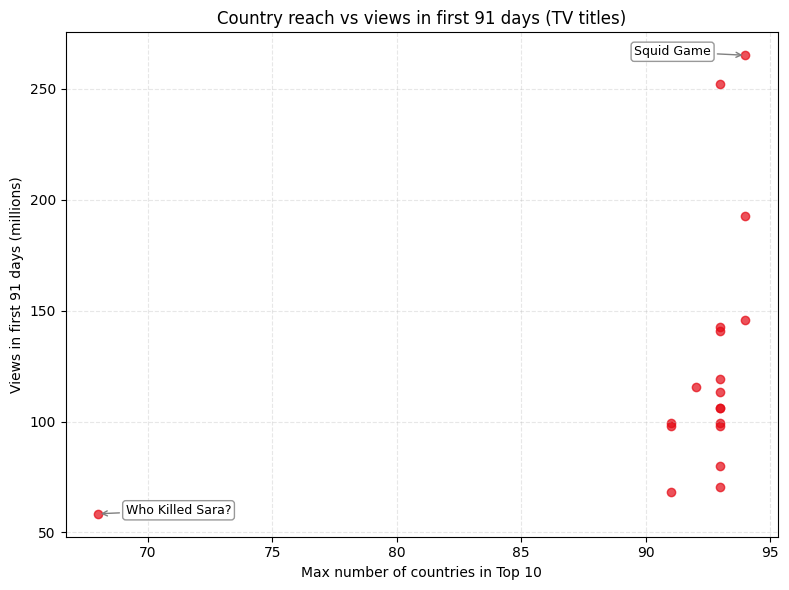

,show_title,category,max_countries,views_first_91_days
9,Squid Game,TV (Non-English),94,265200000
0,Wednesday,TV (English),93,252100000
10,Squid Game,TV (Non-English),94,192600000
11,Squid Game,TV (Non-English),94,145800000
1,Adolescence,TV (English),93,142600000
2,Stranger Things,TV (English),93,140700000
3,Wednesday,TV (English),93,119200000
4,DAHMER,TV (English),92,115600000
5,Bridgerton,TV (English),93,113300000
12,Money Heist,TV (Non-English),93,106000000


In [8]:
# Country reach vs views in first 91 days (TV titles) - in millions

tv_popular = popular[popular["category"].isin(["TV (English)", "TV (Non-English)"])]

popular_with_reach = pd.merge(
    tv_popular,
    title_country_reach[["show_title", "max_countries"]],
    on="show_title",
    how="inner"
)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    popular_with_reach["max_countries"],
    popular_with_reach["views_first_91_days"] / 1e6,
    color=accent_red,
    alpha=0.7
)

plt.title("Country reach vs views in first 91 days (TV titles)")
plt.xlabel("Max number of countries in Top 10")
plt.ylabel("Views in first 91 days (millions)")

# Light grid for readability
plt.grid(True, linestyle="--", alpha=0.3)

# Identify top-viewed title
top_point = popular_with_reach.sort_values(
    "views_first_91_days", ascending=False
).iloc[0]

plt.annotate(
    top_point["show_title"],
    (
        top_point["max_countries"],
        top_point["views_first_91_days"] / 1e6
    ),
    xytext=(-80, 0),
    textcoords="offset points",
    fontsize=9,
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.25",
        fc="white",
        ec="gray",
        alpha=0.8
    ),
    arrowprops=dict(
        arrowstyle="->",
        lw=1,
        color="gray"
    )
)

# Identify bottom-left outlier (lowest views)
bottom_point = popular_with_reach.sort_values(
    "views_first_91_days", ascending=True
).iloc[0]

plt.annotate(
    bottom_point["show_title"],
    (
        bottom_point["max_countries"],
        bottom_point["views_first_91_days"] / 1e6
    ),
    xytext=(20, 0),
    textcoords="offset points",
    fontsize=9,
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.25",
        fc="white",
        ec="gray",
        alpha=0.8
    ),
    arrowprops=dict(
        arrowstyle="->",
        lw=1,
        color="gray"
    )
)

plt.tight_layout()
plt.show()

# Show reference table
popular_with_reach[[
    "show_title",
    "category",
    "max_countries",
    "views_first_91_days"
]].sort_values("views_first_91_days", ascending=False).head(10)